# Eddy Trapping and Transport

In [2]:
from smode_import import *
SMODE_data = '/Users/elise/data/SMODE-data/'

# ACS
TSG = xr.open_dataset('/Users/elise/data/SMODE-data/S_MODE_IOP2_SRIDE23_tsg_met_bio.nc')
TSG = TSG.drop_duplicates(dim='time_bio')
TSG = TSG.drop_duplicates(dim='time')
flowrate_time_bio = TSG['flow_rate_lab_tsg'].interp(time=TSG['time_bio'], method='linear')
TSG['flowrate_time_bio'] = (TSG.chlorophyll_ACS.dims, flowrate_time_bio.values)
TSG

<xarray.Dataset> Size: 40MB
Dimensions:                              (time_bio: 32509, time: 147912,
                                          instrument: 1)
Coordinates:
  * time_bio                             (time_bio) datetime64[ns] 260kB 2023...
    latitude_bio                         (time_bio) float64 260kB ...
    longitude_bio                        (time_bio) float64 260kB ...
  * time                                 (time) datetime64[ns] 1MB 2023-04-07...
    latitude                             (time) float64 1MB ...
    longitude                            (time) float64 1MB ...
Dimensions without coordinates: instrument
Data variables: (12/47)
    TSG86                                (instrument) float64 8B ...
    TSG73                                (instrument) float64 8B ...
    SST62                                (instrument) float64 8B ...
    FLW19                                (instrument) float64 8B ...
    FLW20                                (instrument) float64 8B ...
    FLW09                                (instrument) float64 8B ...
    ...                                   ...
    beam_attenuation_657nm_ACS           (time_bio) float64 260kB ...
    chlorophyll_flourometer              (time_bio) float64 260kB ...
    particulate_organic_carbon_cstar     (time_bio) float64 260kB ...
    photosynthetically_active_radiation  (time_bio) float64 260kB ...
    CSTAR_QCflag                         (time_bio) float64 260kB ...
    flowrate_time_bio                    (time_bio) float64 260kB 2.844 ... 1...
Attributes: (12/52)
    DOI:                           10.5067/SMODE-RVTSG
    title:                         SMODE Shipboard bio-optical, meteorlogical...
    summary:                       Level-2 processed data from GPS, TSG and F...
    keywords:                      EARTH SCIENCE > OCEANS > OPTICS > ATTENUAT...
    keywords_vocabulary:           NASA Global Change Master Directory (GCMD)...
    conventions:                   CF-1.8, ACDD-1.3
    ...                            ...
    timetime_coverage_end:         2023-05-03T15:05:07Z
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  down
    date_created:                  2023-04-13T00:00:00Z
    time_coverage_duration:        P25D20H10M57S
    comment:                       See readme.txt. Thermosalinograph Data are...

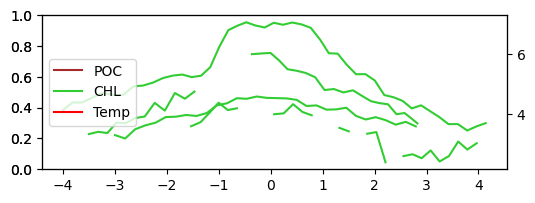

In [3]:
# Function to measure distance between two points
def haversine_array(lons, lats):
    lons = np.radians(lons)
    lats = np.radians(lats)

    lon0, lat0 = lons[0], lats[0]
    dlon = lons - lon0
    dlat = lats - lat0

    a = np.sin(dlat / 2.0)**2 + np.cos(lat0) * np.cos(lats) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371.0  # Earth radius in km
    return c * r  # distance from (lon0, lat0)

#['2023-04-20T03:50:00', '2023-04-20T04:45:00'],
times_eddy = [
    ['2023-04-20T21:30:00', '2023-04-20T22:15:00'],
    ['2023-04-21T16:45:00', '2023-04-21T17:21:00'],
    ['2023-04-22T22:30:00', '2023-04-22T23:00:00'],
    ['2023-04-24T21:55:00', '2023-04-24T22:30:00'],
]

orientation = ['zonal','meridional','meridional','meridional','zonal']
distances = []
distances_bio = []

eddy_core = [4, 3.5, 3, 2.5]

plt.figure(figsize=(6,2))
ax0=plt.gca()
ax1=ax0.twinx()
ax2=ax1.twinx()

for i in range(np.shape(times_eddy)[0]):
    # Time
    TSG_bio_ = TSG.sel(time_bio=slice(times_eddy[i][0],times_eddy[i][1]))
    TSG_ = TSG.sel(time=slice(times_eddy[i][0],times_eddy[i][1]))
    
    # Space
    lat_bio =  TSG_bio_['latitude_bio']
    lon_bio =  TSG_bio_['longitude_bio']
    distance_bio = haversine_array(lon_bio.values,lat_bio.values)
    distances_bio.append(distance_bio)
    
    lat_ =  TSG_['latitude']
    lon_ =  TSG_['longitude']
    distance = haversine_array(lon_.values,lat_.values)
    distances.append(distance)
    
    # Variables
    POC_eddy = TSG_bio_['particulate_organic_carbon_acs']
    CHL_eddy = TSG_bio_['chlorophyll_ACS']
    T_eddy = TSG_['water_temperature_bow']
    
    # Plot
    #ax0.plot(distance-eddy_core[i],T_eddy, 'r')
    #ax1.plot(distance_bio-eddy_core[i],POC_eddy, color='brown')
    ax2.plot(distance_bio-eddy_core[i],CHL_eddy, color='limegreen')
    
plt.plot([],[],color='brown', label='POC')
plt.plot([],[],color='limegreen', label='CHL')
plt.plot([],[],color='r', label='Temp')

plt.legend(loc='center left')
plt.show();


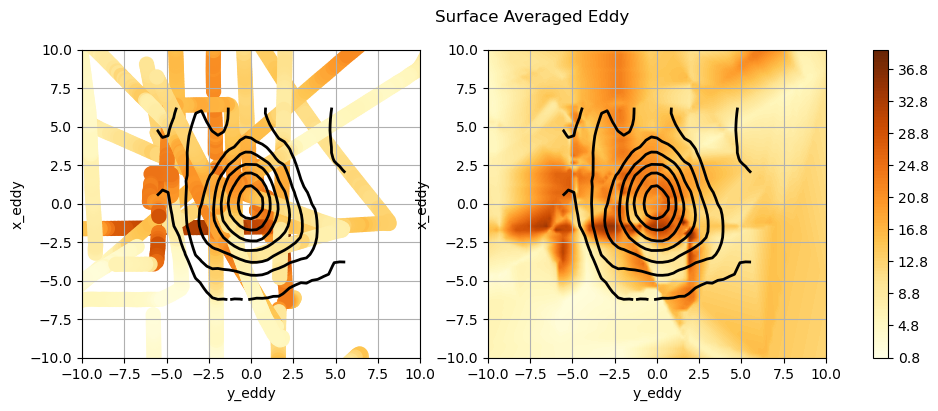

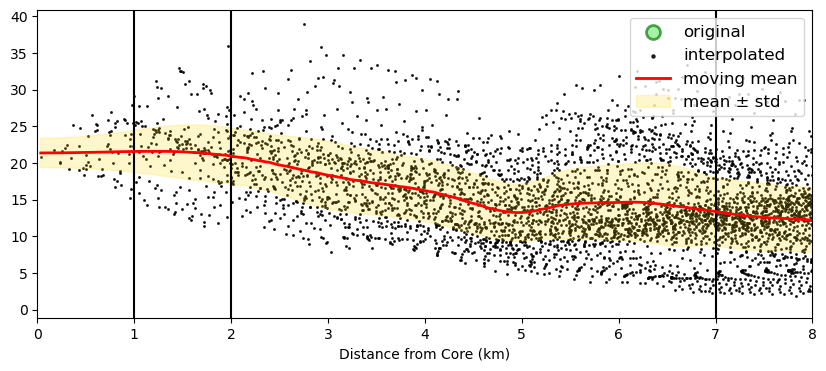

In [4]:
# 
ds_interpolated = xr.open_dataset('eddy_core_position.nc')

# uw data ship
variable = 'poc'

#####
if variable=='chl':
    ACS_eddy_times = TSG['chlorophyll_ACS'].sel(time_bio=slice('2023-04-18','2023-04-23'))
    cmap=cm.delta
    upper_bound = 6
    color='limegreen'
if variable=='poc':
    ACS_eddy_times = TSG['particulate_organic_carbon_acs'].sel(time_bio=slice('2023-04-18','2023-04-23'))
    cmap='YlOrBr'
    upper_bound = 50
    color='gold'
    
# interpolate eddy core time on uw time
ds_interpolated_on_ACS = ds_interpolated.interp(time=ACS_eddy_times.time_bio, method='quadratic')

# find distance in latitude and longitude for each time step
dlat = ds_interpolated_on_ACS.lat - ACS_eddy_times.latitude_bio
dlon = ds_interpolated_on_ACS.lon - ACS_eddy_times.longitude_bio

# convert distance into km
dy_km = dlat * 111320 / 1e3
dx_km = dlon * (111320 * np.cos(np.radians(ds_interpolated_on_ACS.lat.values))) / 1e3
dist_from_core = np.sqrt(dx_km**2 + dy_km**2)

# keep only nighttime values
def is_night(timestamp,delta=-7): #account for photochemical quenching
    # UTC to PST delta=-7
    return (timestamp.dt.hour < 9-delta) | (timestamp.dt.hour >= 17-delta)
idx = (
         (~np.isnan(ACS_eddy_times))
       & (~np.isnan(dy_km))
       & (~np.isnan(dx_km))
       & (ACS_eddy_times<upper_bound)

       & (is_night(ACS_eddy_times.time_bio))
    )

dy_km = dy_km[idx]
dx_km = dx_km[idx]

dataset_ship = xr.Dataset(
    {
    variable: xr.DataArray(ACS_eddy_times.values[idx],dims='dist_from_core'),
    'dist_from_core': xr.DataArray(dist_from_core[idx]),
    },
)
dataset_ship = dataset_ship.sortby('dist_from_core')
dataset_ship


### PLOT ###

fig, ax = plt.subplots(1,2, figsize=(12,4))
p=ax[0].scatter(dx_km, dy_km, c=dataset_ship[variable],
            s=100, cmap=cmap)#, vmin=0, vmax=4)
#plt.colorbar(p,ax=ax[0])
ax[0].set_xlim(-10,10); ax[0].set_ylim(-10,10)
ax[0].grid()

from scipy.interpolate import griddata

# Create grid
xi = np.linspace(dx_km.min(), dx_km.max(), 200)
yi = np.linspace(dy_km.min(), dy_km.max(), 200)
xi, yi = np.meshgrid(xi, yi)

# Interpolate the data onto the grid
zi = griddata((dx_km, dy_km), dataset_ship[variable], (xi, yi), method='linear')
di = np.sqrt(xi.flatten()**2 + yi.flatten()**2)

# Plot with contourf
p=ax[1].contourf(xi, yi, zi, levels=100, cmap=cmap)#, vmin=0, vmax=4)
#plt.colorbar(p,ax=ax[1],label="Chlorophyll")
ax[1].set_xlabel("dx (km)")
ax[1].set_ylabel("dy (km)")
ax[1].set_xlim(-10,10); ax[1].set_ylim(-10,10)
ax[1].grid()
composite_eddy = xr.open_dataset('composite_eddy_centered.nc')
for axis in ax:
    composite_eddy.vor_eddy.plot.contour(levels=np.linspace(-2,2,16),colors='k',linewidths=2,ax=axis)
#(composite_eddy.div_eddy).plot.contour(levels=np.linspace(-2,2,50),colors='k',linewidths=2)

dataset_ship_interpolated = xr.Dataset(
    {
    variable: xr.DataArray(zi.flatten(),dims='dist_from_core'),
    'dist_from_core': xr.DataArray(di, dims='dist_from_core'),
    },
)
dataset_ship_interpolated = dataset_ship_interpolated.sortby('dist_from_core')

plt.suptitle("Surface Averaged Eddy")
fig.colorbar(p,ax=ax)
plt.show()


# smooth ship data from eddy core
data = dataset_ship_interpolated

# Window size for moving mean and std
window_size = 5#500
moving_std = data[variable].rolling(dist_from_core=window_size, center=True, min_periods=1).std()
moving_mean = data[variable].rolling(dist_from_core=window_size, center=True, min_periods=1).mean()
# second smoothing round

from scipy.ndimage import gaussian_filter1d
smooth_std_var = gaussian_filter1d(moving_std, sigma=100, mode='nearest')  # Adjust sigma for smoothing strength
smooth_mean_var = gaussian_filter1d(moving_mean, sigma=100, mode='nearest')

# Set up the figure

plt.figure(figsize=(10, 4))

# Scatter plot for data concentration
plt.scatter([],[], s=100, facecolor='lightgreen', edgecolor='forestgreen', 
            linewidth=2, marker='o', label='original', alpha=0.8,)
plt.scatter(di,zi, s=5, facecolor='k', edgecolor='k', 
             marker='.', alpha=0.8,)
plt.scatter([],[], s=20, facecolor='k', edgecolor='k', 
             marker='.', label='interpolated', alpha=0.8,)

# Plot the moving mean as an red line
plt.plot(data.dist_from_core, smooth_mean_var, color='r', label='moving mean', linewidth=2,zorder=101)

plt.fill_between(data.dist_from_core, 
                 smooth_mean_var - smooth_std_var, 
                 smooth_mean_var + smooth_std_var, 
                 color=color, alpha=0.2, label='mean ± std')

#plt.axhline(0,color='k',linestyle=':')
# Labels, limits, and legend
plt.xlabel('Distance from Core (km)')
#plt.ylabel('Concentration')
#plt.ylim(-2,6)
plt.legend(fontsize=12,loc='upper right')
plt.xlim(0,8)
plt.axvline(1,color='k');plt.axvline(2,color='k');plt.axvline(7,color='k')
plt.show()

# create dataset for composite plot
smooth_mean_var = xr.Dataset(
    {
    f'{variable}_mean': xr.DataArray(smooth_mean_var,dims='dist_from_core'),
    f'{variable}_std': xr.DataArray(smooth_std_var,dims='dist_from_core'),
    'dist_from_core': xr.DataArray(data.dist_from_core.values, dims='dist_from_core'),
    },
)

In [5]:
speed=0
if speed==1:
    fig, ax = plt.subplots(1,2,figsize=(10,4))
    p=ax[0].scatter(ds_interpolated.lon[1:],
                ds_interpolated.lat[1:],
                s=100,
                c=speed_mps,
                cmap='RdBu_r',
                vmin=0, vmax=0.2)
    plt.colorbar(p,ax=ax[0])
    ax[0].set_title(f'Eddy position and speed')
    
    ax[1].hist(speed_mps,30,facecolor='darkred',edgecolor='w')
    ax[1].set_title(f'mean speed = {np.mean(speed_mps):.2f} ms-1')
    plt.show()

In [6]:
haversine(36.5,-124,39.5,-124)

333.5847799336762

### POC export $_{eddy}$ = Biomass x Velocity

In [7]:
TSG['particulate_organic_carbon_acs'].units, TSG['chlorophyll_ACS'].units

('umol L-1', 'ug L-1')

In [8]:
TSG['particulate_organic_carbon_acs'] * 1e-6 * 1e3

<xarray.DataArray 'particulate_organic_carbon_acs' (time_bio: 32509)> Size: 260kB
array([0.009769, 0.009769, 0.009933, ..., 0.036912, 0.038584, 0.036912])
Coordinates:
  * time_bio       (time_bio) datetime64[ns] 260kB 2023-04-10T21:12:00 ... 20...
    latitude_bio   (time_bio) float64 260kB ...
    longitude_bio  (time_bio) float64 260kB ...

In [9]:
# Biomass
idx = ~np.isnan(smooth_mean_var[f'{variable}_mean'])

# 1. Area integrated POC concentration [μg m-1]
r   = smooth_mean_var['dist_from_core'][idx]*1e3 # [km] to [m]
var = smooth_mean_var[f'{variable}_mean'][idx] * 12.01 / 1e-3 # [μmol L-1] * 12.01 = [μg m-3]
var_std = smooth_mean_var[f'{variable}_std'][idx] * 12.01 / 1e-3 # [μg m-3], standard deviation

area_integrated_var     = np.trapz(var * 2 * np.pi * r, r) # [μg m-3 * m2] = [μg m-1]
area_integrated_var_std = np.trapz(var_std * 2 * np.pi * r, r) # [μg m-3 * m2] = [μg m-1] -> std

# 2. Volume integrated POC concentration [μg]
mld = 25 # meters
volume_integrated_var     = area_integrated_var * mld # [μg m-1 * m] = μg
volume_integrated_var_std = area_integrated_var_std * mld # [μg m-1 * m] = [μg] -> std

# 3. Convert Biomass to kg
volume_integrated_var_kg     = volume_integrated_var*1e-9 # [kg]
volume_integrated_var_kg_std = volume_integrated_var_std*1e-9 # [kg]

print(f'Our submesoscale eddy contains: {volume_integrated_var_kg:.2f} kg POC ± {volume_integrated_var_kg_std:.1f} of biomass (assuming constant concentration within top {mld} m)')

print(f'Our submesoscale eddy contains: {volume_integrated_var_kg/1e6:.2f} Gg POC ± {volume_integrated_var_kg_std/1e6:.1f} of biomass (assuming constant concentration within top {mld} m)')


Our submesoscale eddy contains: 2867485.83 kg POC ± 966465.3 of biomass (assuming constant concentration within top 25 m)
Our submesoscale eddy contains: 2.87 Gg POC ± 1.0 of biomass (assuming constant concentration within top 25 m)


In [10]:
# POC Export = [Velocity] x [Biomass] x P*[Average Surface Area]

# 1. Submesoscale eddy velocity [m s-1]
lat = ds_interpolated.lat.values
lon = ds_interpolated.lon.values
time = pd.to_datetime(ds_interpolated.time.values)
distances = [haversine(lat[i], lon[i], lat[i+1], lon[i+1]) for i in range(len(lat)-1)] # km
delta_t = np.diff(time).astype('timedelta64[s]').astype(float) # s
speed_mps = np.array(distances) * 1000 / delta_t
speed_km_per_day = np.array(distances) / (delta_t / 86400)

U = np.mean(speed_mps)
U_std = np.std(speed_mps)

# 2. Concentration [mol C]
idx = ~np.isnan(smooth_mean_var[f'{variable}_mean'])
r   = smooth_mean_var['dist_from_core'][idx]*1e3 # [km] to [m]
var = smooth_mean_var[f'{variable}_mean'][idx] / 1e-3 # [μmol L-1] = [μmol m-3]
var_std = smooth_mean_var[f'{variable}_std'][idx] / 1e-3 # [μmol m-3] -> std
area_integrated_var     = np.trapz(var * 2 * np.pi * r, r) # [μmol m-3 * m2] = [μmol m-1]
area_integrated_var_std = np.trapz(var_std * 2 * np.pi * r, r) # [μmol m-3 * m2] = [μmol m-1] -> std
mld = 25 # meters
volume_integrated_var     = area_integrated_var * mld # [μmol m-1 * m] = μmol
volume_integrated_var_std = area_integrated_var_std * mld # [μmol m-1 * m] = [μmol] -> std

C = volume_integrated_var
C_std = volume_integrated_var_std

# 2. Cross-section area of eddies passed -124W [P= (D_eddy*N_days_eddies)/(Δx*D)]
R_eddy = 5000 #[m], average radius ~5km
D_eddy = 2*R_eddy # eddy diameter [m]
A = D_eddy * mld
dx = 300e3 # 300 km in [m]
N = np.mean(np.array([1.1, 1.6])) # at all time we have between 1.1 and 1.6 eddies
P = D_eddy*N/dx

# 3. Compute Export
ave_speed_mps = -0.1
eddy_POC_export     = volume_integrated_var_kg * ave_speed_mps * P * A
eddy_POC_export_std = volume_integrated_var_kg_std * ave_speed_mps * P * A

# 4. Convert to mmol C
eddy_POC_export_mmol_C    = eddy_POC_export*1e-3
eddy_POC_export_mmol_C_std = eddy_POC_export_std*1e-3

print(f'Our submesoscale eddy export flux is: {eddy_POC_export_mmol_C:.3f} mmol C ± {eddy_POC_export_mmol_C_std:.3f}')



Our submesoscale eddy export flux is: -3225921.557 mmol C ± -1087273.484


In [11]:
# Carbon Export Flux across 124W line

# Inputs
U = np.mean(speed_mps)            # [m/s]
U_std = np.std(speed_mps)         # [m/s]
C_conc = np.mean(var)             # [μmol/m³]
C_std = np.std(var)               # [μmol/m³]
P = D_eddy * N / dx               # Unitless
P_std = (D_eddy * (np.max([1.1, 1.6]) - np.min([1.1, 1.6])) / 2) / dx  # Estimate std from N range

# Compute export flux
flux_per_area = U * C_conc * P              # [μmol/m²/s]
flux_per_area_mmol = flux_per_area / 1e3    # [mmol/m²/s]

# Error propagation
rel_error_squared = (U_std/U)**2 + (C_std/C_conc)**2 + (P_std/P)**2
flux_per_area_std_mmol = flux_per_area_mmol * np.sqrt(rel_error_squared)

# Output
print(f"Export flux: {flux_per_area_mmol:.4f} ± {flux_per_area_std_mmol:.4f} mmol C/m²/s")



Export flux: 0.0434 ± 0.0237 mmol C/m²/s


In [12]:
print(rel_error_squared.values)
print(((U_std/U)**2))
print(((C_std.values/C_conc.values)**2))
print(((P_std/P)**2))

0.29758499686076334
0.13411887948183532
0.12917256456685663
0.03429355281207134


In [13]:
## Extrapolation to CCS

# 1. Average count of cyclonic submesoscale eddies per year 
#N = 13000 # ~13,000/year in SCB from Payandeh et al., 2023
#N = 350 # 350/year in SD from Kim et al., 2010
# NO−3 horizontal transport by mean flow: 64%, mesoscales: 26%, submesoscales: 10% (Damien et al., 2023)
N = 10

# 2. Submesoscale eddies POC export per year
all_eddies_POC_export_Sv     = eddy_POC_export_Sv * N
all_eddies_POC_export_Sv_std = eddy_POC_export_Sv_std * N

print(f'Submesoscale eddies {variable} export per year : {all_eddies_POC_export_Sv:.2f} Sv year-1 +/- {all_eddies_POC_export_Sv_std:.2f} (assuming {N} submesoscale eddies per year)')
print(all_eddies_POC_export_Sv-all_eddies_POC_export_Sv_std)


NameError: name 'eddy_POC_export_Sv' is not defined

In [15]:
N = np.array([10, 30])
mld * surf_area * N / 86400 / 1e6

NameError: name 'surf_area' is not defined

In [16]:
POC_export_flux = 0.1 * volume_integrated_var_kg / (mld * 2*R_eddy)# vel[ms-1] x mass [Gg] / area [m2]
POC_export_flux/12 *1e3 # [mol m3 s-1] # eddy mass flux

95.58286095706448

In [14]:
# 1. Radius and data
r = smooth_mean_var['dist_from_core'][idx] * 1e3  # [km] → [m]
var = smooth_mean_var[f'{variable}_mean'][idx] * 1e3  # [μmol/L] → [μmol/m³]
var_std = smooth_mean_var[f'{variable}_std'][idx] * 1e3  # [μmol/L] → [μmol/m³]

# 2. Area-integrated concentration [μmol/m]
area_integrated_var = np.trapz(var * 2 * np.pi * r, r)  # [μmol/m³ × m²] = [μmol/m]
area_integrated_var_std = np.trapz(var_std * 2 * np.pi * r, r)

# 3. Volume-integrated concentration [μmol]
mld = 25  # m
volume_integrated_var = area_integrated_var * mld  # [μmol]
volume_integrated_var_std = area_integrated_var_std * mld

# 4. Convert to mmol C
volume_integrated_var_mmol = volume_integrated_var / 1e3  # [mmol]
volume_integrated_var_mmol_std = volume_integrated_var_std / 1e3

print(f"Submesoscale eddy contains {volume_integrated_var_mmol:.1f} ± {volume_integrated_var_mmol_std:.1f} mmol C")

# 5. Flux
U = speed_mps.mean()
R = 5e3  # 5 km
A = mld * 2 * R  # m²

flux_mmol_m2_day = (U*86400) * volume_integrated_var / A   # mmol/m²/day
flux_mmol_m2_day


Submesoscale eddy contains 238758187236.6 ± 80471716862.1 mmol C


8136105411181.64

## Decay timesecale

In [20]:
distance_from_coast = 200e3  # meters
average_speed = speed_mps.mean()  # meters per second
delta_time_days = distance_from_coast / average_speed / 86400  # days

C0 = 15  # initial chlorophyll in mg/m^3
Ct = 5   # observed chlorophyll offshore in mg/m^3

decay_timescale_days = -delta_time_days / np.log(Ct / C0)
decay_timescale_days


21.36914965751733

In [69]:
speed_mps.std()

0.036110168766999295